In [1]:
from pathlib import Path
import numpy as np
import os, shutil
import matplotlib.pyplot as plt

from PIL import Image

from tqdm.auto import tqdm

import torch
import torchvision
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torchsummary import summary
from torch.utils.data.dataset import Subset
from torch import nn
from torchvision.models import resnet50, ResNet50_Weights

In [2]:
device = "cuda:1" if torch.cuda.is_available() else "cpu"

# Load a pretrained ResNet Model

In [3]:
resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
model = torch.nn.Sequential(*list(resnet.children())[:-1]).to(device)
model.eval()

for param in model.parameters():
    param.requires_grad = True
del resnet


In [4]:
transform = ResNet50_Weights.DEFAULT.transforms()

transform

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

# Visualize Embeddings

In [5]:
class_labels = []
y_true = []
resnet_features = []

for classes in ['color','good','cut','hole','metal_contamination','thread']:
    folder_path = Path(r"Detection/Carpet/carpet/test/{}".format(classes))
    for pth in tqdm(folder_path.iterdir(), leave = False):
        class_label = pth.parts[-2]

        with torch.no_grad():
            test_image = transform(Image.open(pth)).to(device).unsqueeze(0)
            feature = model(test_image)
            resnet_features.append(feature.squeeze().cpu().detach().numpy())
        class_labels.append(class_label)
        y_true.append(0 if class_label =="good" else 1)

resnet_features = np.array(resnet_features)    

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

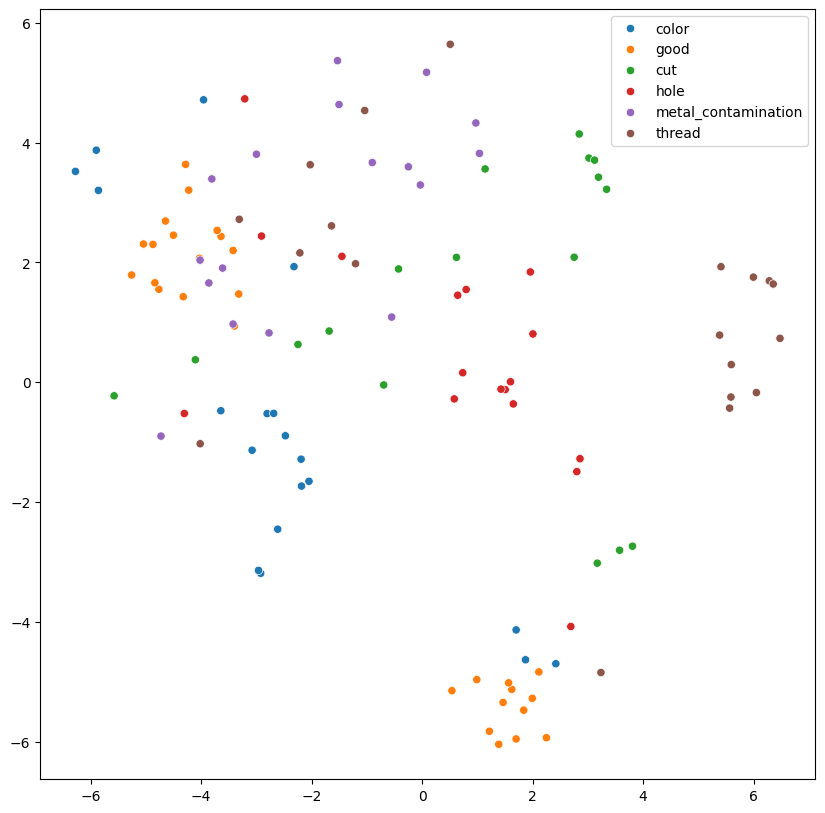

In [6]:
from sklearn.manifold import TSNE
import seaborn as sns
tsne = TSNE(n_components=2, random_state=42)
resnet_features_2d = tsne.fit_transform(resnet_features)

plt.figure(figsize=(10, 10))
sns.scatterplot(x = resnet_features_2d[:,0], y = resnet_features_2d[:, 1], hue = class_labels )
plt.show()

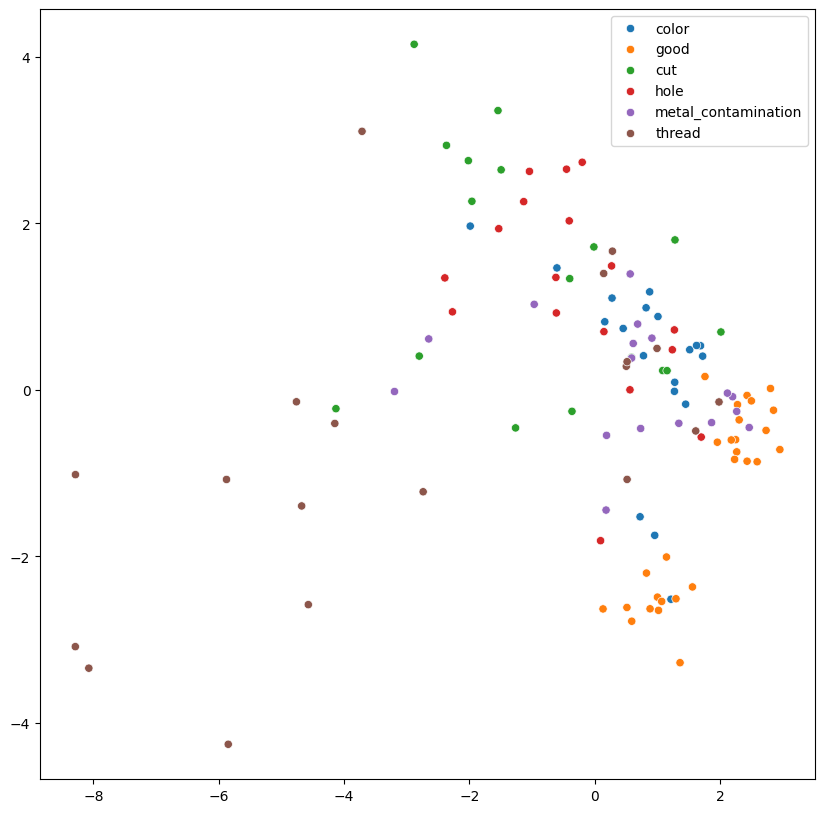

In [8]:
from sklearn.decomposition import PCA
import numpy as np

# Assume resnet_features is [num_images, 2048]
pca = PCA(n_components=2)
resnet_features_2d = pca.fit_transform(resnet_features)

plt.figure(figsize=(10, 10))
sns.scatterplot(x = resnet_features_2d[:,0], y = resnet_features_2d[:, 1], hue = class_labels )
plt.show()

# Create a memory bank

In [7]:
memory_bank = []
folder_path = Path(r'Detection/Carpet/carpet/train/good')
for pth in tqdm(folder_path.iterdir(), leave = False):
    with torch.no_grad():
        data = transform(Image.open(pth)).to(device).unsqueeze(0)
        features = model(data)
        memory_bank.append(features.squeeze().cpu().detach())

memory_bank = torch.stack(memory_bank).to(device)


0it [00:00, ?it/s]

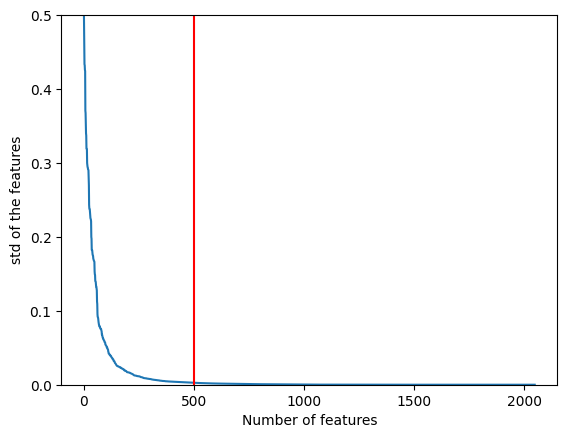

In [8]:
value, indices = torch.sort(memory_bank.std(dim=0))
plt.plot(value.cpu().numpy()[::-1])
plt.vlines(x=500,ymin=0,ymax=0.5,colors='red')
plt.ylim([0,0.5])
plt.ylabel("std of the features")
plt.xlabel("Number of features")
plt.show()

In [9]:
values, indices =torch.sort(memory_bank.std(dim=0))
selected_indices = indices[-500:]
memory_bank = memory_bank[:, selected_indices]

In [10]:
memory_bank.shape

torch.Size([280, 500])

# For Ok images K- nearest neighbours

In [11]:
y_score = []
k =50
folder = Path(r"Detection/Carpet/carpet/train/good")
for pth in tqdm(folder.iterdir(), leave = False):
    data = transform(Image.open(pth)).to(device).unsqueeze(0)
    with torch.no_grad():
        features = model(data).squeeze()
    dist, _ =torch.sort(torch.norm(memory_bank - features[selected_indices], dim = 1))
    dist = dist[:k].mean()
    y_score.append(dist.cpu().numpy())


0it [00:00, ?it/s]

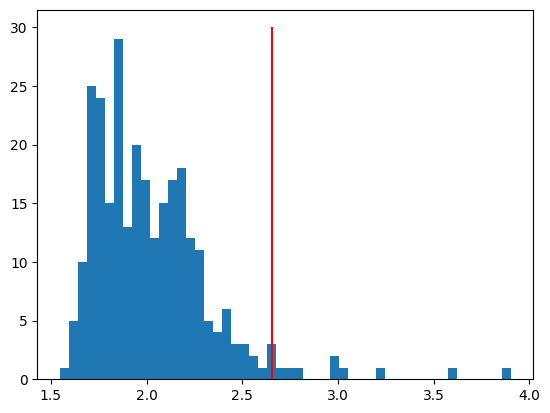

In [12]:
best_threshold = np.mean(y_score) +  2 * np.std(y_score)
plt.hist(y_score, bins = 50)
plt.vlines(x = best_threshold, ymin = 0, ymax = 30, color = 'r')
plt.show()


In [16]:
# values,indices = torch.sort(memory_bank.std(dim=0))
# selected_indices = indices[-500:]
# memory_bank = memory_bank[:,selected_indices]

# For notOk images K- nearest neighbours

In [21]:

folder_path =  Path(r"Detection/Carpet/carpet/test/color")

class_labels = []
y_true = []
resnet_features = []
y_score = []

for classes in ['color','good','cut','hole','metal_contamination','thread']:
    folder_path =Path(r"Detection/Carpet/carpet/test/{}".format(classes))

    for pth in tqdm(folder_path.iterdir(),leave=False):
        class_label = pth.parts[-2]
        with torch.no_grad():
            test_image = transform(Image.open(pth)).to(device).unsqueeze(0)
            features = model(test_image).squeeze()
            dist, _ = torch.sort(torch.norm(memory_bank - features[selected_indices], dim =1))
            dist = dist[:k].mean()
            y_score.append(dist.cpu().numpy())
            
        class_labels.append(class_label)
        y_true.append(0 if class_label == "good" else 1)
        

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

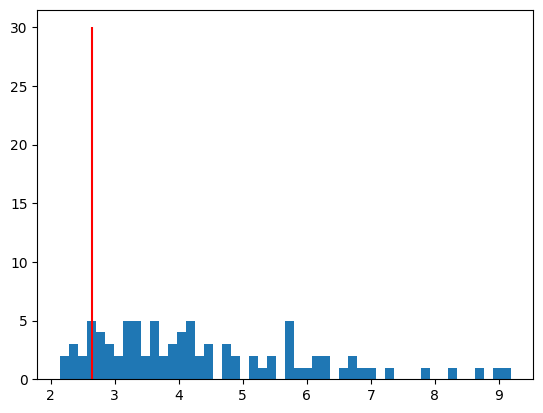

In [22]:

y_score_nok = [score  for score,true in zip(y_score,y_true) if true==1]
plt.hist(y_score_nok,bins=50)
plt.vlines(x=best_threshold,ymin=0,ymax=30,color='r')
plt.show()

AUC-ROC Score: 0.7395666131621188


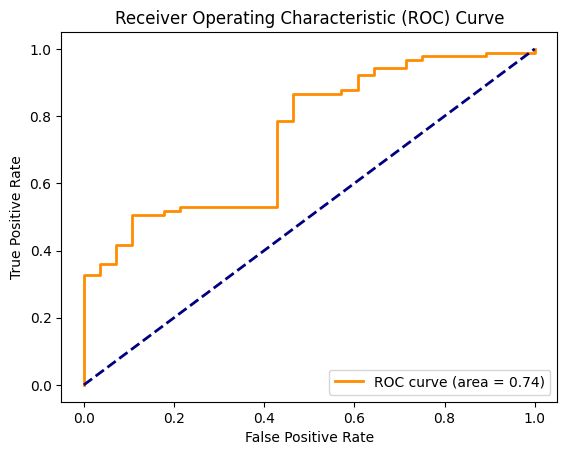

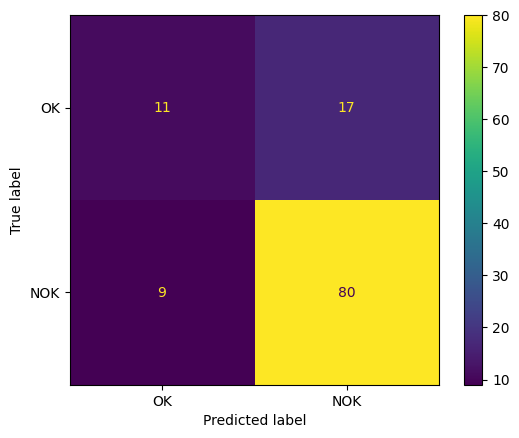

In [23]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, f1_score


# Calculate AUC-ROC score
auc_roc_score = roc_auc_score(y_true, y_score)
print("AUC-ROC Score:", auc_roc_score)

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_score)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_roc_score)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



# Generate confusion matrix
cm = confusion_matrix(y_true, (y_score >= best_threshold).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['OK','NOK'])
disp.plot()
plt.show()